In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  
import seaborn as sns

In [69]:
df =pd.read_csv("data-export (1).csv")

In [70]:
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [71]:
df.columns=df.iloc[0]
df.head()

,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [72]:
df = df.drop(index= 0).reset_index(drop = True)
df.columns=["channel group","date hour","user","sessions"," engaged session"," average engagement time per session","engagement time per user","events per session ","engagement rate","event count"]
df.head()  

,channel group,date hour,user,sessions,engaged session,average engagement time per session,engagement time per user,events per session,engagement rate,event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   channel group                         3182 non-null   object
 1   date hour                             3182 non-null   object
 2   user                                  3182 non-null   object
 3   sessions                              3182 non-null   object
 4    engaged session                      3182 non-null   object
 5    average engagement time per session  3182 non-null   object
 6   engagement time per user              3182 non-null   object
 7   events per session                    3182 non-null   object
 8   engagement rate                       3182 non-null   object
 9   event count                           3182 non-null   object
dtypes: object(10)
memory usage: 248.7+ KB


In [74]:
df["date hour"] = pd.to_datetime(
    df["date hour"],
    format="%Y%m%d%H",
    errors='coerce'
)

numeric_cols = df.columns.drop(["channel group", "date hour"])

df[numeric_cols] = df[numeric_cols].apply(
    pd.to_numeric,
    errors='coerce'
)

df["hour"] = df["date hour"].dt.hour

In [75]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   channel group                         3182 non-null   object        
 1   date hour                             3182 non-null   datetime64[ns]
 2   user                                  3182 non-null   int64         
 3   sessions                              3182 non-null   int64         
 4    engaged session                      3182 non-null   int64         
 5    average engagement time per session  3182 non-null   float64       
 6   engagement time per user              3182 non-null   float64       
 7   events per session                    3182 non-null   float64       
 8   engagement rate                       3182 non-null   float64       
 9   event count                           3182 non-null   int64         
 10  

In [76]:
df.head()

,channel group,date hour,user,sessions,engaged session,average engagement time per session,engagement time per user,events per session,engagement rate,event count,hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [77]:
df.describe()

,date hour,user,sessions,engaged session,average engagement time per session,engagement time per user,events per session,engagement rate,event count,hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441216,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


In [78]:
#session and user over time 

sns.set(style="whitegrid")

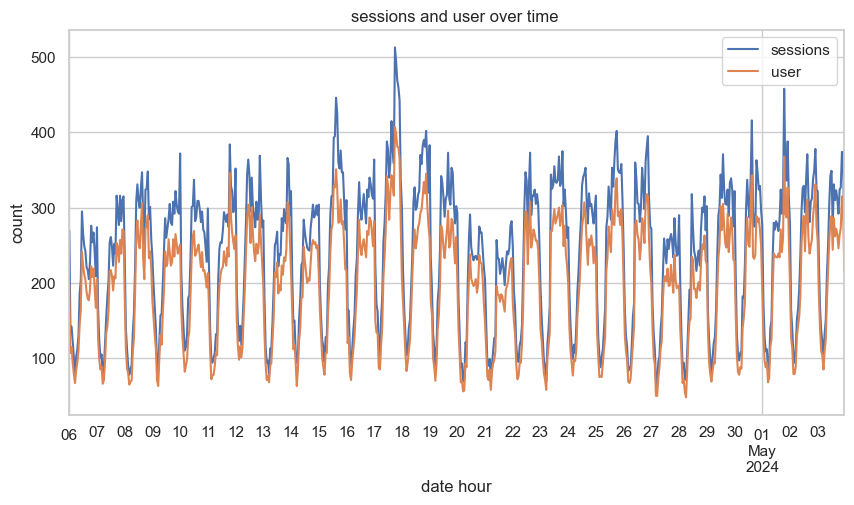

In [79]:
plt.figure(figsize=(10,5))
df.groupby("date hour")[["sessions","user"]].sum().plot(ax=plt.gca())
plt.title("sessions and user over time ")
plt.xlabel("date hour")
plt.ylabel("count")
plt.show()

#total users by channel 

C:\Users\YASH YADAV\AppData\Local\Temp\ipykernel_33100\2410294134.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x="channel group",y="user",estimator=np.sum ,palette="viridis")


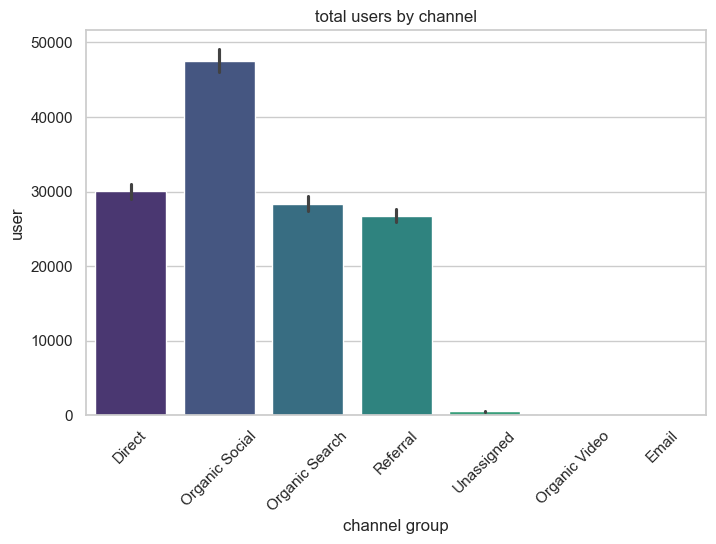

In [80]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="channel group",y="user",estimator=np.sum ,palette="viridis")
plt.title("total users by channel")
plt.xticks(rotation=45)
plt.show()

In [81]:
df.head()


,channel group,date hour,user,sessions,engaged session,average engagement time per session,engagement time per user,events per session,engagement rate,event count,hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


#average engagement time by channel

In [82]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="channel group",
    y="average engagement time per sessionn",
    estimator=np.mean,
    palette="magma"
)

plt.title("Average Engagement Time by Channel")
plt.xticks(rotation=45)
plt.show()

ValueError: Could not interpret value `average engagement time per sessionn` for `y`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>

In [83]:
print(df.columns.tolist())

['channel group', 'date hour', 'user', 'sessions', ' engaged session', ' average engagement time per session', 'engagement time per user', 'events per session ', 'engagement rate', 'event count', 'hour']


In [84]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="channel group",
    y="average engagement time per session",
    estimator=np.mean,
    palette="magma"
)

plt.title("Average Engagement Time by Channel")
plt.xticks(rotation=45)
plt.show()

ValueError: Could not interpret value `average engagement time per session` for `y`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>

In [85]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns.tolist())

['channel group', 'date hour', 'user', 'sessions', 'engaged session', 'average engagement time per session', 'engagement time per user', 'events per session', 'engagement rate', 'event count', 'hour']


In [86]:
print("average engagement time per session" in df.columns)

True


In [87]:
print(type(df))
print(df.columns)
print(df.columns[df.columns.duplicated()])


<class 'pandas.core.frame.DataFrame'>
Index(['channel group', 'date hour', 'user', 'sessions', 'engaged session',
       'average engagement time per session', 'engagement time per user',
       'events per session', 'engagement rate', 'event count', 'hour'],
      dtype='object')
Index([], dtype='object')


In [88]:
print(type(df))

print(df.columns)

print(df[["channel group", "average engagement time per session"]].head())

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index(['channel group', 'date hour', 'user', 'sessions', 'engaged session',
       'average engagement time per session', 'engagement time per user',
       'events per session', 'engagement rate', 'event count', 'hour'],
      dtype='object')
    channel group  average engagement time per session
0          Direct                            47.526667
1  Organic Social                            32.097378
2          Direct                            39.939914
3  Organic Social                            32.160156
4  Organic Social                            46.918552
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   channel group                        3182 non-null   object        
 1   date hour                            3182 non-null   date

In [89]:
import seaborn as sns
print(sns.__version__)

0.13.2


    channel group  average engagement time per session
0          Direct                            47.526667
1  Organic Social                            32.097378
2          Direct                            39.939914
3  Organic Social                            32.160156
4  Organic Social                            46.918552


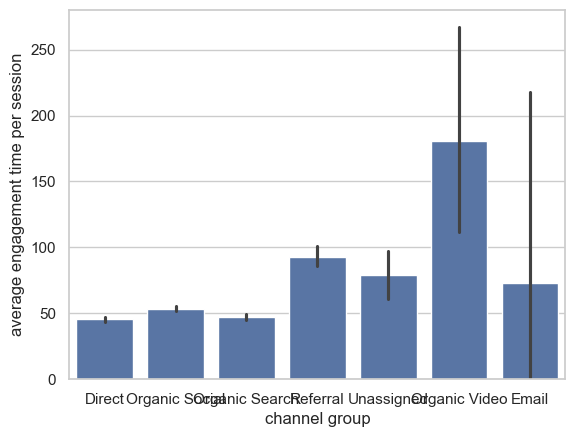

In [90]:
test_df = df[["channel group", "average engagement time per session"]].copy()

print(test_df.head())

sns.barplot(
    data=test_df,
    x="channel group",
    y="average engagement time per session",
    estimator=np.mean
)

plt.show()

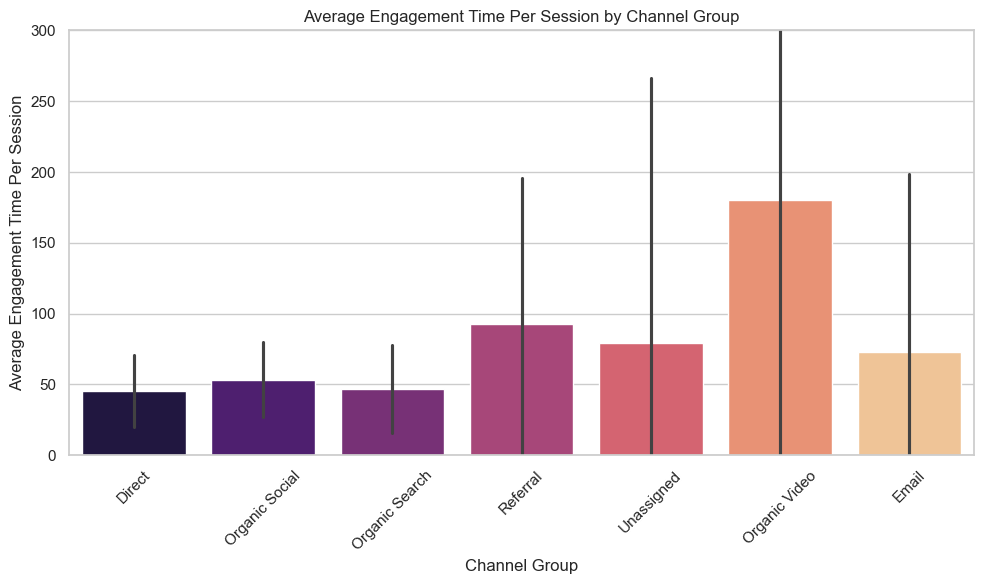

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="channel group",
    y="average engagement time per session",
    estimator=np.mean,
    errorbar="sd",
    hue="channel group",
    palette="magma",
    legend=False
)

plt.title("Average Engagement Time Per Session by Channel Group")
plt.xlabel("Channel Group")
plt.ylabel("Average Engagement Time Per Session")

# Rotate x-axis labels
plt.xticks(rotation=45)

# Y-axis starts at 0 with intervals of 50
plt.ylim(0, 300)                    # Set upper limit as needed
plt.yticks(np.arange(0, 301, 50))   # 0, 50, 100, 150, 200, 250, 300

plt.tight_layout()
plt.show()

#engagement rate distribution by channel 

C:\Users\YASH YADAV\AppData\Local\Temp\ipykernel_33100\2473179345.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="channel group",y="engagement rate",palette="coolwarm")


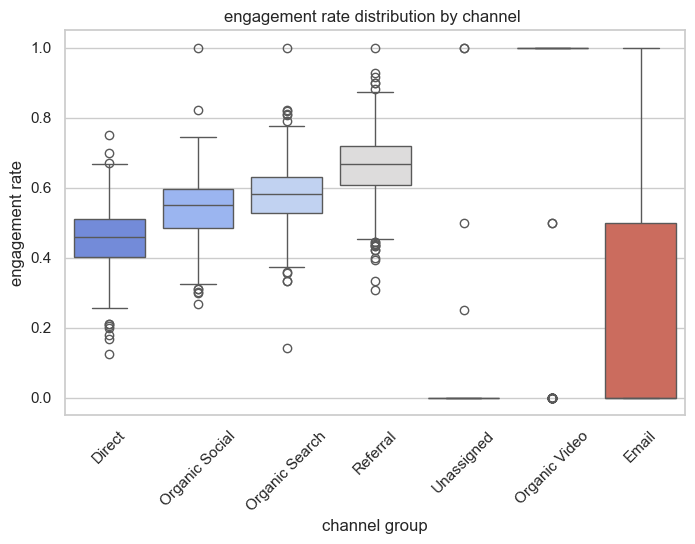

In [92]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="channel group",y="engagement rate",palette="coolwarm")
plt.title("engagement rate distribution by channel ")
plt.xticks(rotation=45)
plt.show()

#engaged vs non engaged session

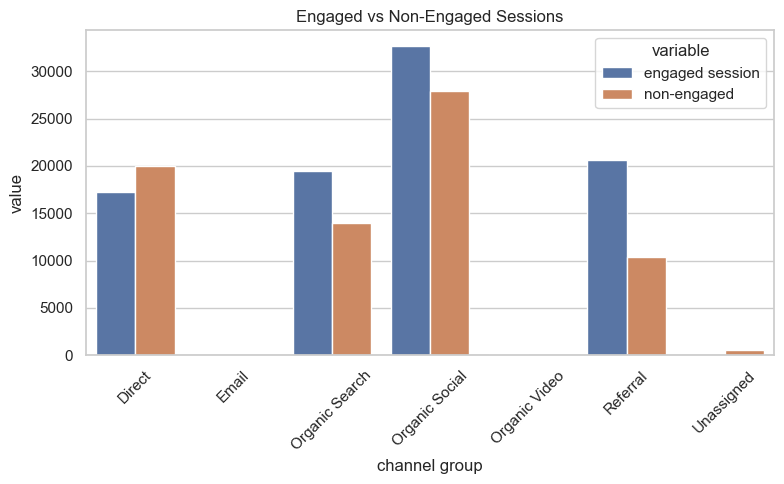

In [93]:
session_df = df.groupby("channel group")[["sessions", "engaged session"]].sum().reset_index()

session_df["non-engaged"] = session_df["sessions"] - session_df["engaged session"]

session_df_melted = session_df.melt(
    id_vars="channel group",
    value_vars=["engaged session", "non-engaged"]
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=session_df_melted,
    x="channel group",
    y="value",
    hue="variable"
)

plt.title("Engaged vs Non-Engaged Sessions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#traffic by hour and channel

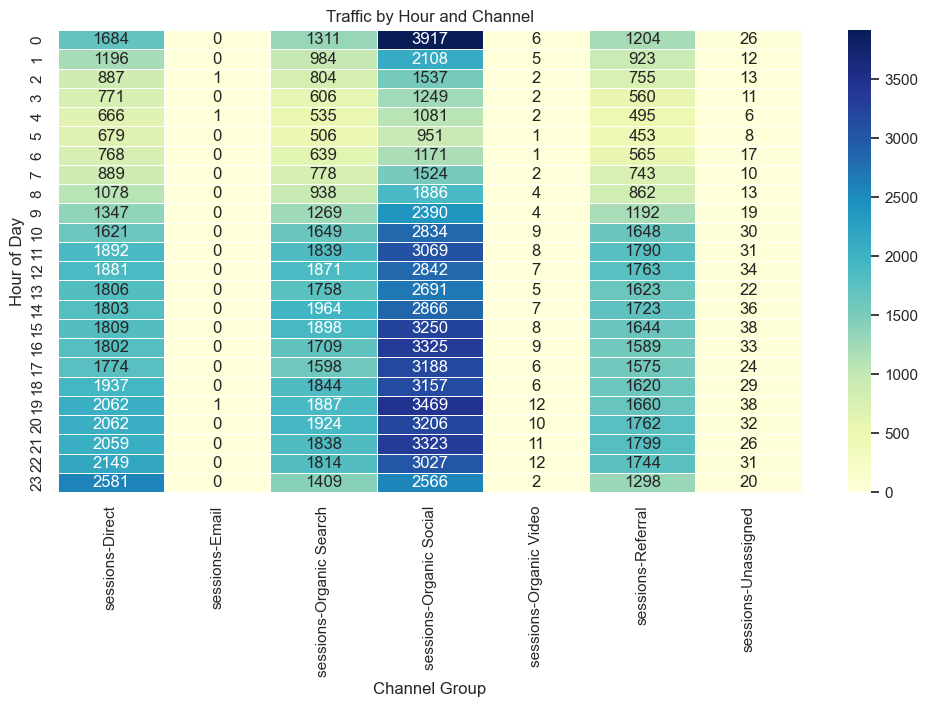

In [94]:
heatmap_data = df.groupby(["hour", "channel group"])[["sessions"]].sum().unstack().fillna(0)

plt.figure(figsize=(12, 6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    annot=True,
    fmt=".0f"
)

plt.title("Traffic by Hour and Channel")
plt.xlabel("Channel Group")
plt.ylabel("Hour of Day")

plt.show()

#engagemnet rate vs session over time 

C:\Users\YASH YADAV\AppData\Local\Temp\ipykernel_33100\1901727824.py:23: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


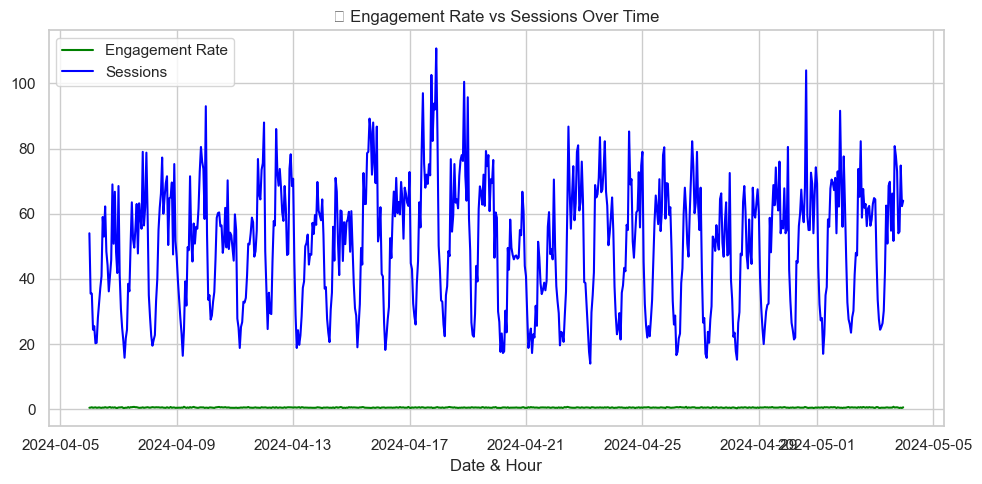

In [95]:
df_plot = df.groupby("date hour")[["engagement rate", "sessions"]].mean().reset_index()

plt.figure(figsize=(10, 5))

plt.plot(
    df_plot["date hour"],
    df_plot["engagement rate"],
    label="Engagement Rate",
    color="green"
)

plt.plot(
    df_plot["date hour"],
    df_plot["sessions"],
    label="Sessions",
    color="blue"
)

plt.title("📊 Engagement Rate vs Sessions Over Time")
plt.xlabel("Date & Hour")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()